# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Farid Wijdan | 5054251042 |

## Deskripsi Tugas
Di tugas ini saya membangun model SVM Classifier untuk memprediksi kanker payudara jinak/ganas.

Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data (fitur-fiturnya hasil pengukuran inti sel, targetnya kolom `diagnosis`: M = ganas, B = jinak)

Tujuannya biar paham praktik SVM, khususnya:
1. Bedanya kernel Linear vs kernel RBF
2. Pengaruh parameter `C` dan `gamma` ke overfitting/underfitting


# 1. Persiapan Dataset dan Eksplorasi Awal


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load dataset
df = pd.read_csv('data.csv')

# buang kolom id dan Unnamed: 32 (isinya kosong semua, tidak kepakai)
df = df.drop(columns=['id', 'Unnamed: 32'])

print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
df.head()
df.info()
df.describe()
print('\nJumlah missing value per kolom:')
print(df.isnull().sum().sum())

Jumlah baris: 569
Jumlah kolom: 31
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  ar

diagnosis
B    357
M    212
Name: count, dtype: int64


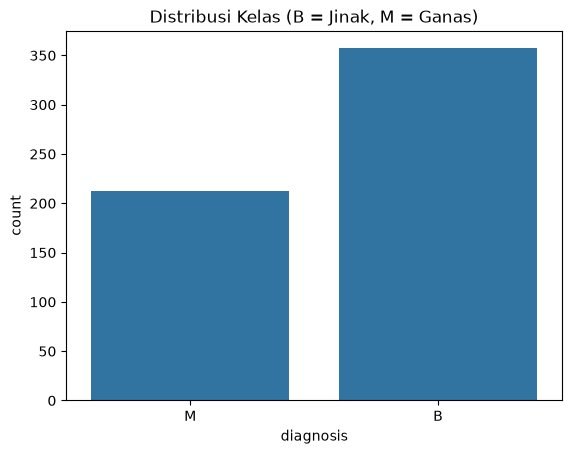

In [3]:
# distribusi kelas target (M = ganas, B = jinak)
print(df['diagnosis'].value_counts())

sns.countplot(x='diagnosis', data=df)
plt.title('Distribusi Kelas (B = Jinak, M = Ganas)')
plt.show()
# datanya tidak terlalu imbalanced, perbandingannya 357 vs 212

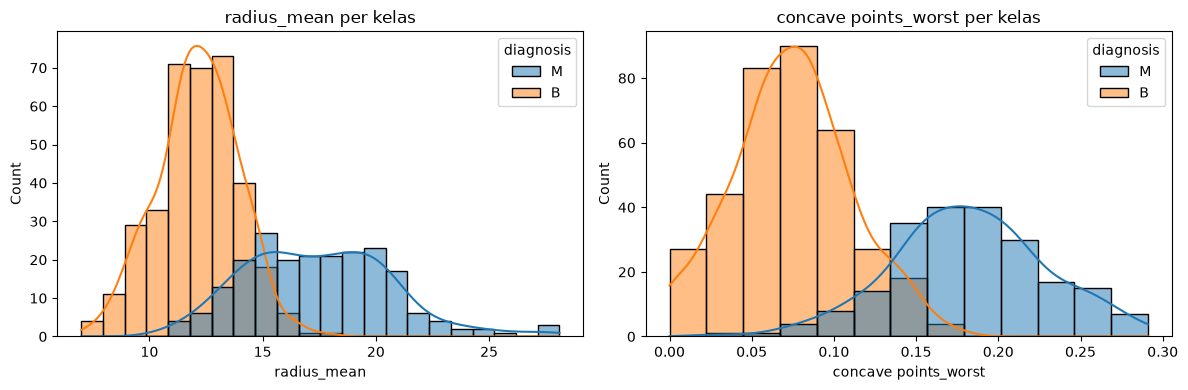

In [4]:
# lihat sebaran fitur: histogram 2 fitur dibedakan per kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, ax=axes[0])
axes[0].set_title('radius_mean per kelas')
sns.histplot(data=df, x='concave points_worst', hue='diagnosis', kde=True, ax=axes[1])
axes[1].set_title('concave points_worst per kelas')
plt.tight_layout()
plt.show()
# beberapa fitur kelihatan cukup kepisah antar kelas (misal concave points_worst)

## EDA tambahan: korelasi antar fitur


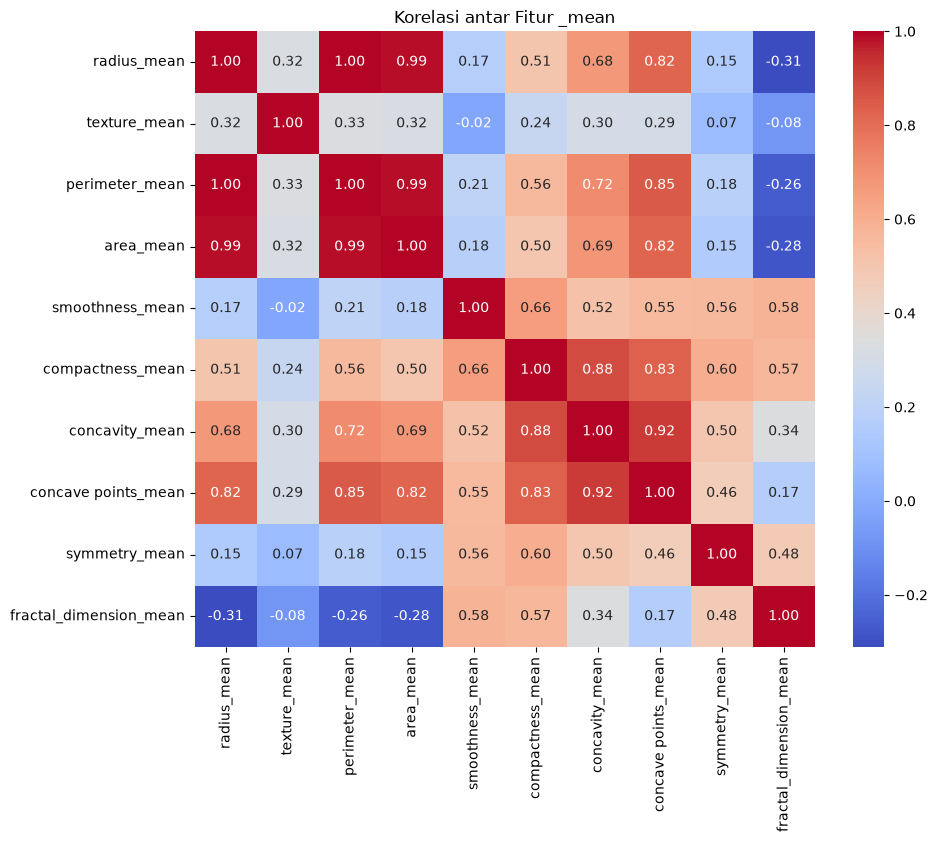

In [5]:
# heatmap korelasi untuk 10 fitur _mean saja biar tidak terlalu penuh
fitur_mean = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(10, 8))
sns.heatmap(df[fitur_mean].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi antar Fitur _mean')
plt.show()
# banyak fitur yang korelasinya tinggi (misal radius, perimeter, area), wajar karena ketiganya sama-sama ukuran tumor

# 2. Preprocessing


In [6]:
# cek missing value (kolom kosong Unnamed: 32 sudah dibuang di awal)
print('Total missing:', df.isnull().sum().sum())
df = df.fillna(df.median(numeric_only=True))
print('Missing setelah dibersihkan:', df.isnull().sum().sum())

Total missing: 0
Missing setelah dibersihkan: 0


In [7]:
# ubah target teks jadi angka: M (ganas) = 1, B (jinak) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print(df['diagnosis'].value_counts())
# fitur lain sudah numerik semua jadi tidak perlu encoding lagi

diagnosis
0    357
1    212
Name: count, dtype: int64


In [8]:
# pisahkan fitur (X) dan target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# split 80:20 pakai stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (455, 30)
X_test : (114, 30)


**Catatan:** SVM itu algoritma berbasis jarak (margin dihitung dari posisi antar titik), jadi sensitif sama skala fitur. Fitur yang rentangnya besar bisa mendominasi padahal belum tentu lebih penting. Makanya fitur numerik wajib di-scaling dulu pakai `StandardScaler`. Scaler cuma di-`fit` ke train set, terus dipakai `transform` ke train dan test, biar tidak data leakage.


In [9]:
# scaling: fit ke train saja, lalu transform keduanya
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Rata-rata X_train setelah scaling (harusnya ~0):', X_train_s.mean().round(2))

Rata-rata X_train setelah scaling (harusnya ~0): 0.0


# 3. Eksperimen Model


## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus tanpa proyeksi ke dimensi lebih tinggi. Dipakai sebagai baseline, apalagi dari EDA tadi datanya kelihatan cukup kepisah.


In [10]:
# latih SVM kernel linear (data yang sudah discaling)
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_s, y_train)
print('Selesai training. Jumlah support vectors:', svm_linear.n_support_)

Selesai training. Jumlah support vectors: [19 19]


In [11]:
# prediksi ke test set
pred_linear = svm_linear.predict(X_test_s)
print('Akurasi (linear):', accuracy_score(y_test, pred_linear))

Akurasi (linear): 0.9649122807017544


## 3.2 SVM dengan Kernel RBF

Kernel RBF memproyeksikan data ke ruang berdimensi lebih tinggi lewat kernel trick, jadi bisa menangani batas keputusan yang non-linear.


In [12]:
# latih SVM kernel rbf, nilai C disamakan (1.0) biar adil
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_s, y_train)
print('Selesai training. Jumlah support vectors:', svm_rbf.n_support_)

Selesai training. Jumlah support vectors: [50 57]


In [13]:
# prediksi ke test set
pred_rbf = svm_rbf.predict(X_test_s)
print('Akurasi (rbf):', accuracy_score(y_test, pred_rbf))

Akurasi (rbf): 0.9736842105263158


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin yang lebar vs toleransi salah klasifikasi, sedangkan `gamma` (khusus RBF) mengatur seberapa lokal pengaruh tiap titik data. Di sini saya coba beberapa nilai `C` dengan `gamma='scale'`.


In [14]:
# coba C = 0.01, 0.1, 1, 10, 100 pakai kernel rbf
daftar_C = [0.01, 0.1, 1, 10, 100]
model_C = {}
for c in daftar_C:
    m = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    m.fit(X_train_s, y_train)
    model_C[c] = m
print('Selesai training', len(model_C), 'model')

Selesai training 5 model


In [15]:
# hitung akurasi train dan test tiap nilai C
skor_train, skor_test = [], []
for c in daftar_C:
    m = model_C[c]
    skor_train.append(m.score(X_train_s, y_train))
    skor_test.append(m.score(X_test_s, y_test))
    print(f'C={c}: train={skor_train[-1]:.4f}, test={skor_test[-1]:.4f}')

C=0.01: train=0.6264, test=0.6316
C=0.1: train=0.9538, test=0.9474
C=1: train=0.9868, test=0.9737
C=10: train=0.9890, test=0.9737
C=100: train=1.0000, test=0.9649


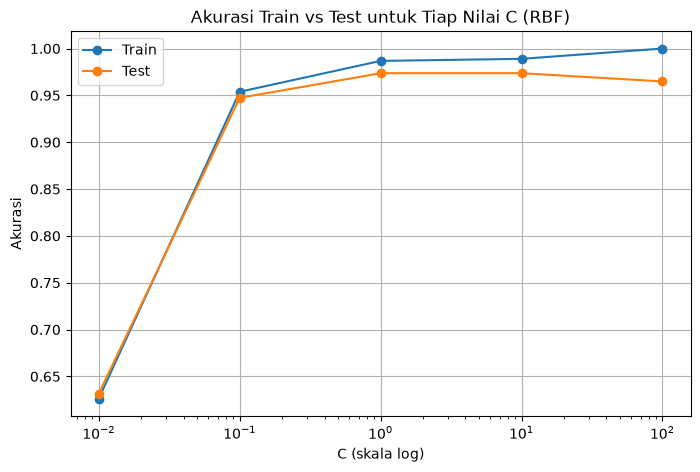

In [16]:
# plot akurasi training vs testing, sumbu x logaritmik karena C kelipatan 10
plt.figure(figsize=(8, 5))
plt.plot(daftar_C, skor_train, marker='o', label='Train')
plt.plot(daftar_C, skor_test, marker='o', label='Test')
plt.xscale('log')
plt.xlabel('C (skala log)')
plt.ylabel('Akurasi')
plt.title('Akurasi Train vs Test untuk Tiap Nilai C (RBF)')
plt.legend()
plt.grid(True)
plt.show()
# C kecil underfit, C besar overfit (train 1.0 tapi test malah turun)

# 4. Evaluasi Model


In [17]:
# tabel perbandingan metrik linear vs rbf
hasil = pd.DataFrame({
    'Linear': [accuracy_score(y_test, pred_linear),
               precision_score(y_test, pred_linear),
               recall_score(y_test, pred_linear),
               f1_score(y_test, pred_linear)],
    'RBF': [accuracy_score(y_test, pred_rbf),
            precision_score(y_test, pred_rbf),
            recall_score(y_test, pred_rbf),
            f1_score(y_test, pred_rbf)]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(hasil.round(4))

           Linear     RBF
Accuracy   0.9649  0.9737
Precision  1.0000  1.0000
Recall     0.9048  0.9286
F1-Score   0.9500  0.9630


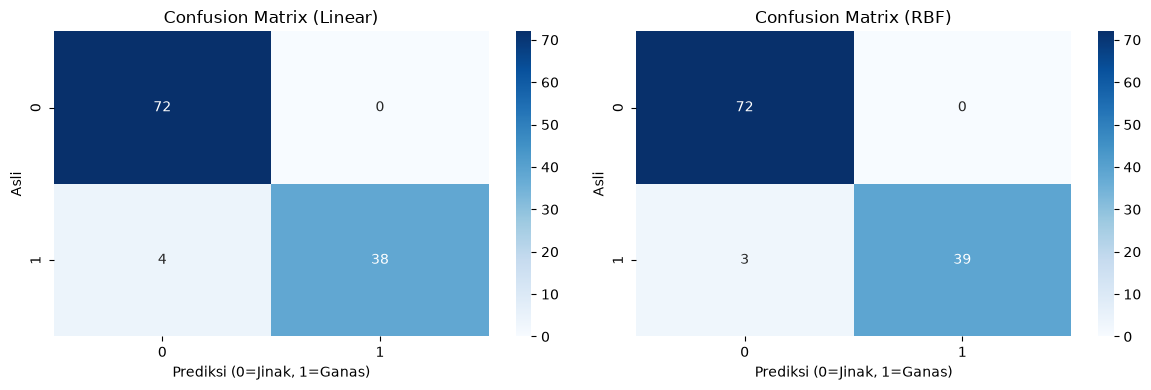

In [18]:
# confusion matrix linear vs rbf dijejerkan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, judul in zip(axes, [pred_linear, pred_rbf], ['Linear', 'RBF']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix ({judul})')
    ax.set_xlabel('Prediksi (0=Jinak, 1=Ganas)')
    ax.set_ylabel('Asli')
plt.tight_layout()
plt.show()

Support vectors Linear: [19 19] -> total: 38
Support vectors RBF   : [50 57] -> total: 107


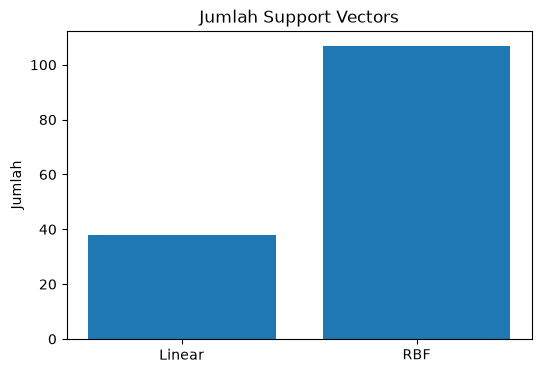

In [19]:
# bandingkan jumlah support vectors linear vs rbf
print('Support vectors Linear:', svm_linear.n_support_, '-> total:', svm_linear.n_support_.sum())
print('Support vectors RBF   :', svm_rbf.n_support_, '-> total:', svm_rbf.n_support_.sum())

plt.figure(figsize=(6, 4))
plt.bar(['Linear', 'RBF'], [svm_linear.n_support_.sum(), svm_rbf.n_support_.sum()])
plt.title('Jumlah Support Vectors')
plt.ylabel('Jumlah')
plt.show()
# RBF butuh support vectors lebih banyak karena batas keputusannya lebih kompleks

Akurasi model 2D (PCA) di test: 0.9298


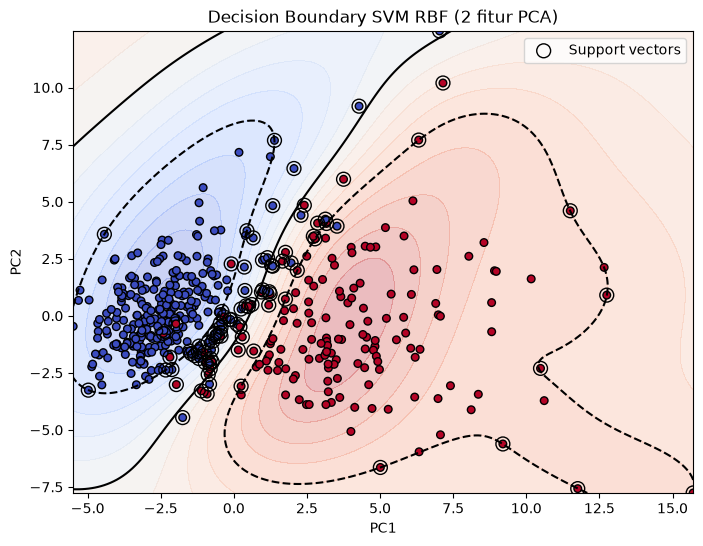

In [20]:
# visualisasi decision boundary: data direduksi ke 2D pakai PCA dulu biar bisa digambar
# (model ini dilatih ulang di 2 fitur PCA khusus buat visualisasi)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_s)
X_test_2d = pca.transform(X_test_s)

svm_2d = SVC(kernel='rbf', C=1.0, random_state=42)
svm_2d.fit(X_train_2d, y_train)
print('Akurasi model 2D (PCA) di test:', round(svm_2d.score(X_test_2d, y_test), 4))

# gambar boundary + support vectors
xx, yy = np.meshgrid(np.linspace(X_train_2d[:, 0].min(), X_train_2d[:, 0].max(), 200),
                     np.linspace(X_train_2d[:, 1].min(), X_train_2d[:, 1].max(), 200))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.3)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=30)
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
            facecolors='none', edgecolors='k', s=100, label='Support vectors')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary SVM RBF (2 fitur PCA)')
plt.legend()
plt.show()

# 5. Analisis

**Linear vs RBF:** RBF sedikit lebih bagus (akurasi 0,9737 vs 0,9649) dengan precision sama-sama 1,0000 alias tidak ada kasus jinak yang salah dibilang ganas. Recall RBF juga lebih tinggi (0,9286 vs 0,9048). Menurut saya wajar karena dari EDA ada fitur yang sebarannya tumpang tindih antar kelas, jadi batas lurus saja kurang cukup dan proyeksi RBF ke dimensi lebih tinggi membantu. Tapi bedanya kecil, artinya data ini memang sudah hampir linearly separable.

**Eksperimen nilai C:** di C=0,01 model jelas underfit (train 0,6264, test 0,6316), margin-nya terlalu lebar sampai banyak data salah klasifikasi. Naik ke C=0,1 langsung lompat (test 0,9474), lalu C=1 dan C=10 jadi titik terbaik (test 0,9737). Di C=100 gejala overfitting muncul: akurasi train sudah 1,0000 (hafal semua data training) tapi akurasi test malah turun ke 0,9649. Cirinya sama seperti biasa: garis train naik terus sampai mentok, garis test stagnan lalu menurun.

**Support vectors:** model Linear cuma butuh 38 support vectors (19 + 19), sedangkan RBF butuh 107 (50 + 57). Ini masuk akal karena batas keputusan RBF lebih kompleks/berlekuk-lekuk jadi butuh lebih banyak titik penopang. Selain itu makin besar C, jumlah support vectors makin sedikit (341 di C=0,01 turun sampai 70 di C=100) karena margin-nya makin sempit dan model makin yakin, yang ujung-ujungnya bikin overfitting.


# 6. Kesimpulan dan Saran

**Kesimpulan:** SVM bekerja sangat baik di dataset ini, RBF (0,9737) sedikit mengalahkan Linear (0,9649). Parameter C terbukti krusial: terlalu kecil bikin underfit, terlalu besar bikin overfit, yang paling pas di sekitar C=1 sampai 10. Feature scaling juga penting karena SVM berbasis jarak, tanpa scaling fitur seperti `area_mean` yang nilainya ratusan bakal mendominasi.

**Saran:** (1) coba kernel Polynomial sebagai pembanding; (2) lakukan hyperparameter tuning yang proper pakai GridSearchCV untuk C dan gamma sekaligus dengan cross-validation; (3) bandingkan dengan model lain seperti Logistic Regression atau Random Forest.
